# Understanding the Boxplot

A boxplot (box-and-whisker plot) compresses a distribution into **five key statistics** — minimum fence, Q1, median, Q3, and maximum fence — plus individually plotted outliers. It is the fastest way to compare distributions across groups.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

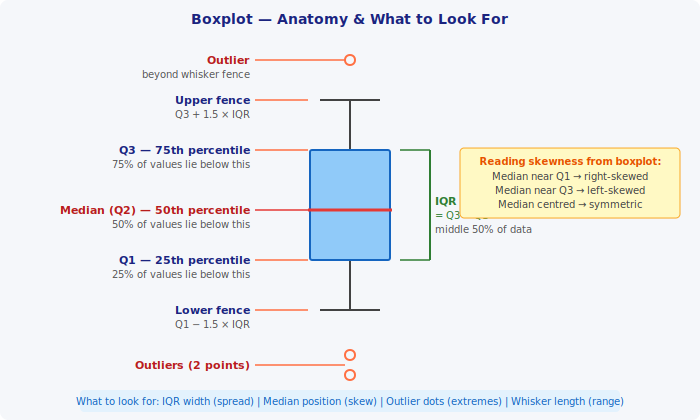

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="420"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="420" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Boxplot — Anatomy &amp; What to Look For</text>

  <!-- ── Vertical boxplot, centred at x=350 ── -->
  <!-- y=60  = upper outlier               -->
  <!-- y=100 = upper whisker (Q3+1.5*IQR)  -->
  <!-- y=150 = Q3                          -->
  <!-- y=210 = Median (Q2)                 -->
  <!-- y=260 = Q1                          -->
  <!-- y=310 = lower whisker (Q1-1.5*IQR)  -->
  <!-- y=355 = lower outlier               -->
  <!-- box width = 80, centered at x=350   -->

  <!-- whisker lines -->
  <line x1="350" y1="100" x2="350" y2="150" stroke="#424242" stroke-width="2"/>
  <line x1="350" y1="260" x2="350" y2="310" stroke="#424242" stroke-width="2"/>
  <!-- whisker caps -->
  <line x1="320" y1="100" x2="380" y2="100" stroke="#424242" stroke-width="2"/>
  <line x1="320" y1="310" x2="380" y2="310" stroke="#424242" stroke-width="2"/>

  <!-- IQR box -->
  <rect x="310" y="150" width="80" height="110" fill="#90CAF9" stroke="#1565C0" stroke-width="2" rx="2"/>

  <!-- Median line -->
  <line x1="308" y1="210" x2="392" y2="210" stroke="#E53935" stroke-width="3"/>

  <!-- Outliers -->
  <circle cx="350" cy="60"  r="5" fill="none" stroke="#FF7043" stroke-width="2"/>
  <circle cx="350" cy="355" r="5" fill="none" stroke="#FF7043" stroke-width="2"/>
  <circle cx="350" cy="375" r="5" fill="none" stroke="#FF7043" stroke-width="2"/>

  <!-- ── LEFT ANNOTATIONS ── -->

  <!-- Upper outlier -->
  <line x1="345" y1="60" x2="255" y2="60" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="64" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Outlier</text>
  <text x="250" y="78" text-anchor="end" font-size="10" fill="#555">beyond whisker fence</text>

  <!-- Upper whisker -->
  <line x1="308" y1="100" x2="255" y2="100" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="104" text-anchor="end" font-size="11" font-weight="bold" fill="#1A237E">Upper fence</text>
  <text x="250" y="118" text-anchor="end" font-size="10" fill="#555">Q3 + 1.5 × IQR</text>

  <!-- Q3 -->
  <line x1="308" y1="150" x2="255" y2="150" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="154" text-anchor="end" font-size="11" font-weight="bold" fill="#1A237E">Q3 — 75th percentile</text>
  <text x="250" y="168" text-anchor="end" font-size="10" fill="#555">75% of values lie below this</text>

  <!-- Median -->
  <line x1="308" y1="210" x2="255" y2="210" stroke="#E53935" stroke-width="1.5"/>
  <text x="250" y="214" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Median (Q2) — 50th percentile</text>
  <text x="250" y="228" text-anchor="end" font-size="10" fill="#555">50% of values lie below this</text>

  <!-- Q1 -->
  <line x1="308" y1="260" x2="255" y2="260" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="264" text-anchor="end" font-size="11" font-weight="bold" fill="#1A237E">Q1 — 25th percentile</text>
  <text x="250" y="278" text-anchor="end" font-size="10" fill="#555">25% of values lie below this</text>

  <!-- Lower whisker -->
  <line x1="308" y1="310" x2="255" y2="310" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="314" text-anchor="end" font-size="11" font-weight="bold" fill="#1A237E">Lower fence</text>
  <text x="250" y="328" text-anchor="end" font-size="10" fill="#555">Q1 − 1.5 × IQR</text>

  <!-- Lower outliers -->
  <line x1="345" y1="365" x2="255" y2="365" stroke="#FF7043" stroke-width="1.5"/>
  <text x="250" y="369" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Outliers (2 points)</text>

  <!-- ── RIGHT ANNOTATIONS ── -->

  <!-- IQR bracket -->
  <line x1="400" y1="150" x2="430" y2="150" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="400" y1="260" x2="430" y2="260" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="430" y1="150" x2="430" y2="260" stroke="#2E7D32" stroke-width="2"/>
  <text x="435" y="205" font-size="11" font-weight="bold" fill="#2E7D32">IQR</text>
  <text x="435" y="219" font-size="10" fill="#2E7D32">= Q3 − Q1</text>
  <text x="435" y="233" font-size="10" fill="#555">middle 50% of data</text>

  <!-- Skew hint: median closer to Q1 → right skewed -->
  <rect x="460" y="148" width="220" height="70" fill="#FFF9C4" rx="4" stroke="#F9A825" stroke-width="1"/>
  <text x="570" y="165" text-anchor="middle" font-size="10" font-weight="bold" fill="#E65100">Reading skewness from boxplot:</text>
  <text x="570" y="180" text-anchor="middle" font-size="10" fill="#424242">Median near Q1 → right-skewed</text>
  <text x="570" y="194" text-anchor="middle" font-size="10" fill="#424242">Median near Q3 → left-skewed</text>
  <text x="570" y="208" text-anchor="middle" font-size="10" fill="#424242">Median centred    → symmetric</text>

  <!-- takeaway -->
  <rect x="80" y="390" width="540" height="22" fill="#E3F2FD" rx="4"/>
  <text x="350" y="405" text-anchor="middle" font-size="10" fill="#1565C0">
    What to look for:  IQR width (spread)  |  Median position (skew)  |  Outlier dots (extremes)  |  Whisker length (range)
  </text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Boxplot

| Feature | What it tells you |
|---|---|
| **Box height (IQR)** | Spread of the middle 50% — tall box = high variability |
| **Median line position** | Central tendency; asymmetric position reveals skew |
| **Whisker length** | How far the non-outlier data extends |
| **Outlier dots** | Individual points beyond 1.5 × IQR from the box |
| **Narrow box, long whiskers** | Data is concentrated but with extreme values |
| **Side-by-side boxplots** | Instant group comparison — medians, spreads, outliers |

**Limitation**: hides the distribution *shape* within the box — a bimodal and a symmetric distribution can produce identical boxplots. Pair with a violin plot when shape matters.

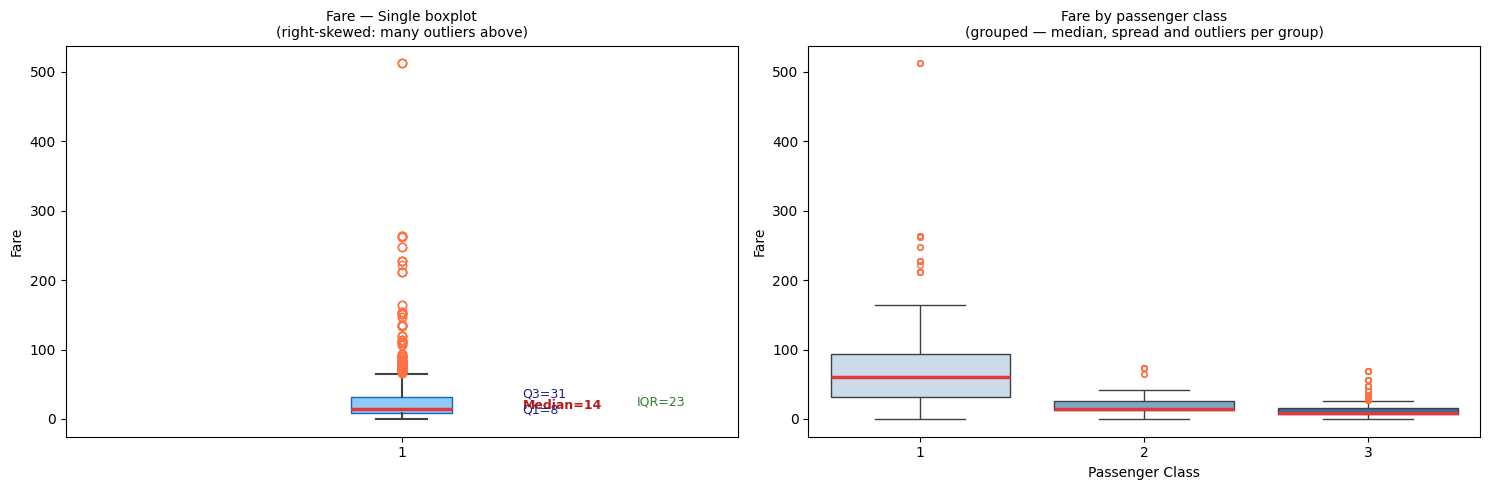

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Single annotated boxplot
bp = axes[0].boxplot(df['fare'].dropna(), patch_artist=True, vert=True,
                     boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                     medianprops=dict(color='#E53935', linewidth=2.5),
                     whiskerprops=dict(color='#424242', linewidth=1.5),
                     capprops=dict(color='#424242', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='#FF7043', markersize=6))

fare = df['fare'].dropna()
q1, med, q3 = fare.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1

axes[0].annotate(f'Q3={q3:.0f}', xy=(1, q3), xytext=(1.18, q3),
                 fontsize=9, color='#1A237E', ha='left')
axes[0].annotate(f'Median={med:.0f}', xy=(1, med), xytext=(1.18, med),
                 fontsize=9, color='#B71C1C', ha='left', fontweight='bold')
axes[0].annotate(f'Q1={q1:.0f}', xy=(1, q1), xytext=(1.18, q1),
                 fontsize=9, color='#1A237E', ha='left')
axes[0].annotate(f'IQR={iqr:.0f}', xy=(1.35, (q1+q3)/2), fontsize=9,
                 color='#2E7D32', ha='left')
axes[0].set_title('Fare — Single boxplot\n(right-skewed: many outliers above)', fontsize=10)
axes[0].set_ylabel('Fare')

# Grouped boxplot: fare by pclass
sns.boxplot(x='pclass', y='fare', data=df, ax=axes[1],
            palette='Blues',
            medianprops=dict(color='#E53935', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='none',
                           markeredgecolor='#FF7043', markersize=4))
axes[1].set_title('Fare by passenger class\n(grouped — median, spread and outliers per group)', fontsize=10)
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

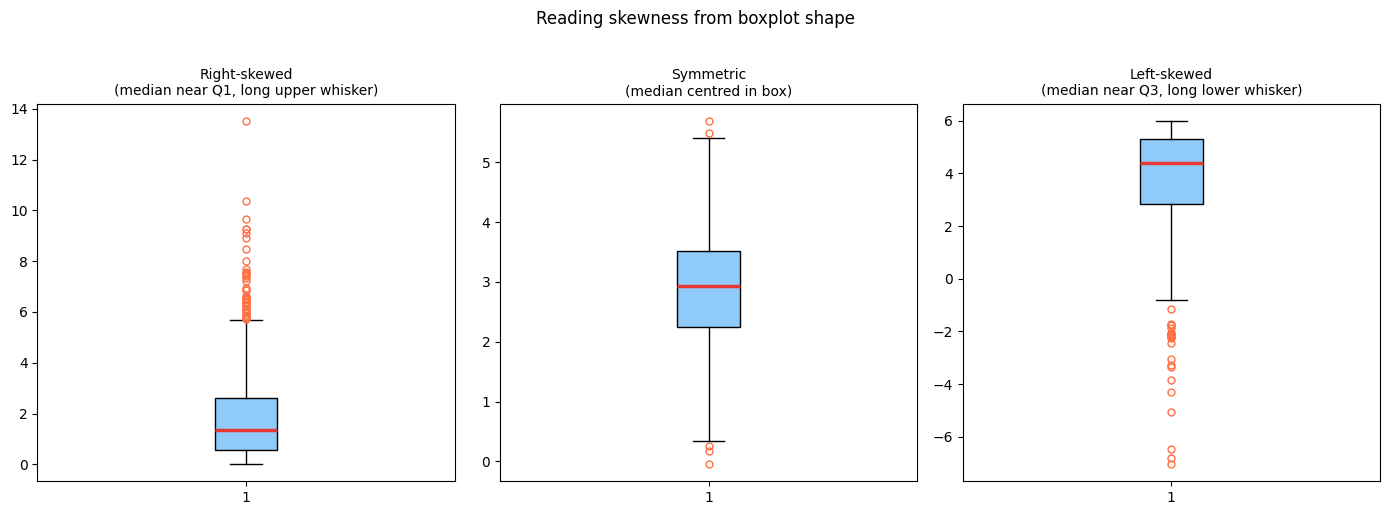

In [4]:
# Demonstrate the skewness reading
np.random.seed(0)
right_skew = np.random.exponential(scale=2, size=500)
symmetric  = np.random.normal(loc=3, scale=1, size=500)
left_skew  = 6 - np.random.exponential(scale=2, size=500)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, data, title in zip(
    axes,
    [right_skew, symmetric, left_skew],
    ['Right-skewed\n(median near Q1, long upper whisker)',
     'Symmetric\n(median centred in box)',
     'Left-skewed\n(median near Q3, long lower whisker)']
):
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9'),
               medianprops=dict(color='#E53935', linewidth=2.5),
               flierprops=dict(marker='o', markerfacecolor='none',
                              markeredgecolor='#FF7043', markersize=5))
    ax.set_title(title, fontsize=10)

plt.suptitle('Reading skewness from boxplot shape', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Comparing distributions across groups |
| **IQR** | Robust measure of spread — not affected by outliers |
| **Outlier rule** | Any point beyond Q1/Q3 ± 1.5×IQR is flagged |
| **Skewness** | Where the median sits within the box |
| **Limitation** | Hides shape inside the box — use with violin plot |